## Introduction

<div style="text-align: justify"> 
What makes a tournament experience successful? There are many aspects to these questions: the venue, the organisation, the tables, food etc. 
I would like to tackle the question from the perspective of the actual games. As a Tournament Organiser (TO), what should you prioritise when designing a pairing and scoring system? Do you want a system that maximises the chances that the best player wins the event? Or would you rather have a system that keeps games as balanced and enjoyable as possible for players of all skill levels? And for that matter, what does it even mean to be "the best player"?

In this article, I try to define and quantify a number of tournament criteria. I then compare two scoring systems, Northern Kings and Black Jack, to see how they perform against these criteria. I also study how small variations of these systems  can affect the overall tournament experience.

The goal is not to find the one perfect scoring system. Different tournaments have different objectives. Instead, the aim is to provide TOs with some data and insights that can help them choose the system that best matches the type of event they want to run.

To do this, I use Monte Carlo simulations—which is a fancy way of saying that I let a computer play out thousands of tournaments and record the results. This is equivalent to throwing a lot of dice, which seems appropriate for evaluating a kings of war pairing system!

The results suggest that, for the criteria considered here, there is little reason to use the Black Jack system, as it tends to perform worse in most situations. The Northern Kings system appears fairly robust, although no scoring system proves capable of consistently identifying and ranking the strongest players perfectly. </div>

## Plan

This article is organised as follows:

* **[Simulation design](#simulation):** how the tournament simulator works and the assumptions used in the model.
* **[Scoring systems](#scoring):** a summary of the Northern Kings and Black Jack systems, together with the variations considered in this study.
* **[Evaluation criteria](#metrics):** the metrics used to assess and compare scoring systems.
* **[Results](#results):** a comparison of the different scoring systems against the selected criteria.
* **[Discussion](conclusion):** an interpretation of the results, the conclusions that can be drawn from them, and the limitations of the study.


<a id="simulation"></a>
## I. Simulation design 

This section discusses the grunt work necessary to run our tests, ie writing up code that allows us to simulate a game of Kings Of War and, by extension, a tournament.
This can probably be entirely skipped if you are not interested in the matter, although you might want to at least take a look at the [Strength Of Schedule (SOS)](#sos) computation.

I use a ELO-like system to allocate a theoretical value to the player/list combination, from which I derive probabilities of winning, as well as a mean to evaluate the score (according to the rulebook). 

Although I make several assumptions that are all described, the tests have been realised using multiple variations of these assumptions and always ended up being coherent.

### Generating player profiles

<div style="text-align: justify"> 
To simulate our tournament, let us first generate "player profiles". I use the ELO system to determine the relative probability of each player winning a game. I use the common chess interpretation for this (although assuming a smaller gap between the very best players and the average ones). Thus, an ELO of 1000 is used for a beginner, an average player has an ELO around 1200–1400, your local club champion is around 1800–2000, and I arbitrarily assume our national masters are around 2200. Clearly, as with all arbitrary decisions in this discussion, this could be subject to debate, but hopefully we observe similar patterns when varying these parameters.

For now, I consider a 32-player tournament, which nicely converges to a maximum of one player with five wins if winners only play against winners, in which case ideally this player should be the winner (we will see that unfortunately this is not always the case).

Later on, I consider larger tournaments to cover cases such as the Clash of Kings tournament, which gathers about 200 players.

Later, we also study how a different ELO distribution can affect the outcomes of our study.</div> 

In [6]:
N_PLAYERS = 32
MIN_ELO = 1300
MAX_ELO = 2200
AVG_ELO = 1400
NUM_ROUNDS = 5 if N_PLAYERS <= 32 else 6  # 5 rounds for up to 32 players, 6 for larger fields

### Probability of Winning Based on ELO Ratings

What does it mean to have a certain ELO rating? 
For two players, Player A and Player B, with ELO ratings $( R_A )$ and $( R_B )$ respectively, the expected score (probability of winning) for player A can be calculated using the following formulas:

$$ E_A = \frac{1}{1 + 10^{(R_B - R_A) / 400}} $$

So what are the chances of a  local club champion to beat a national master?
let's see:

In [7]:
def win_probability(rating_a, rating_b):
    """
    Compute the probability of Player A winning against Player B based on their Elo ratings.
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    float: Probability of Player A winning.
    """
    prob_a = 1 / (1 + 10 ** ((rating_b - rating_a) / 400))
    
    return prob_a


rating_a = 1750
rating_b = 2200

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 7.0%
Probability of Player B winning: 93.0%


What about a very good local club champion vs a top player ?

In [8]:
rating_a = 2000
rating_b = 2200

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 24.0%
Probability of Player B winning: 76.0%


Let us also check that two equivalent players have similar chances of winning

In [9]:
rating_a = 1300
rating_b = 1300

prob_a = win_probability(rating_a, rating_b)

print(f"Probability of Player A winning: {prob_a * 100.:.1f}%")
print(f"Probability of Player B winning: {100*(1.-prob_a):.1f}%")

Probability of Player A winning: 50.0%
Probability of Player B winning: 50.0%


### Generating 32 players

I will now generate player profiles, with a normal distribution centered around 1400 and plot the resulting ELOs to check that this is somewhat what we expect in terms of player distribution. To check that the distribution is what we expect I ll generate more than 32, say 10000 instead, otherwise the results will not be representative.

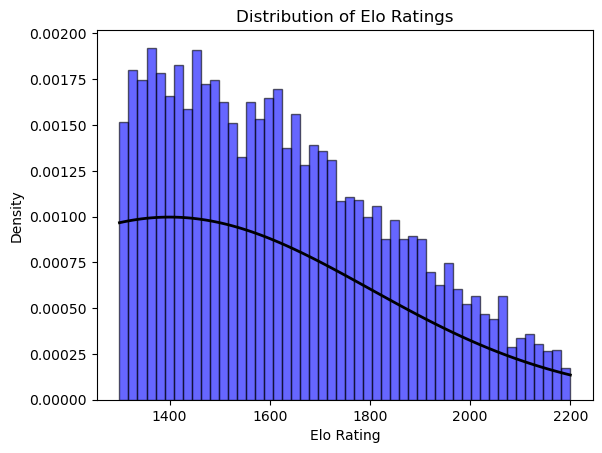

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import truncnorm

std_dev = 400
def generate_normal_elo_ratings(num_ratings=N_PLAYERS, mean=AVG_ELO, std_dev=std_dev, lower_bound=MIN_ELO, upper_bound=MAX_ELO):
    X = truncnorm((lower_bound - mean) / std_dev, (upper_bound - mean) / std_dev, loc=mean, scale=std_dev) 
    return X.rvs(num_ratings)

def plot_ratings(elo_ratings):# Plot the histogram of Elo ratings
    plt.hist(elo_ratings, bins=50, density=True, alpha=0.6, color='b', edgecolor='black')

    # Plot the normal distribution curve
    xmin, xmax = MIN_ELO, MAX_ELO
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, AVG_ELO, std_dev)
    plt.plot(x, p, 'k', linewidth=2)

    # Add titles and labels
    plt.title('Distribution of Elo Ratings')
    plt.xlabel('Elo Rating')
    plt.ylabel('Density')

    # Show the plot
    plt.show()

elo_ratings = generate_normal_elo_ratings(num_ratings=10000)
plot_ratings(elo_ratings)



Ok, it looks like our code runs correctly. In average our players have an ELO of 1400 and only a minority will be among the very top. To generate a set of player profiles I can now simply call:

In [11]:
player_profiles = generate_normal_elo_ratings()

Let's plot an example of player profiles for one tournament, sorted by their theoretical ELOs.

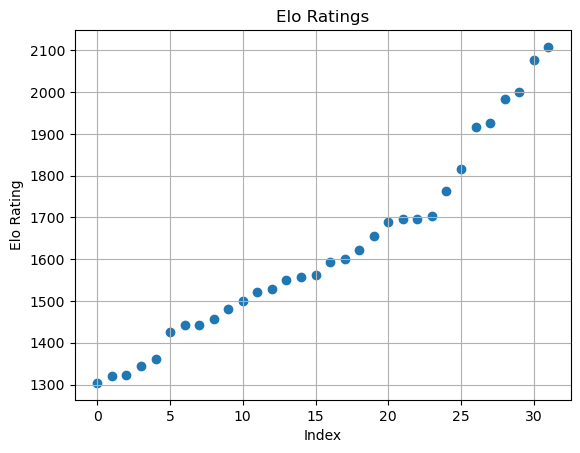

In [12]:
player_profiles = sorted(generate_normal_elo_ratings())
indices = list(range(len(player_profiles)))
plt.scatter(indices, player_profiles)
plt.title('Elo Ratings')
plt.xlabel('Index')
plt.ylabel('Elo Rating')
plt.grid(True)
plt.show()

In this event there are a few beginners, a good distribution of average players, few local champions and one contendent for the Uk masters! In our tests we will run several instances of tournaments under different systems to obtain a comparison of the outcomes as fair as possible

### Simulating a game.

To play a game, we already know the probability for a player A to win against player B, but this is insufficient to determine the outcome of a KOW game according to the main scoring systems. Indeed, we need to consider draws, Kill points and scenario points.

#### Win, Loss or draw ? 
The ELO system does not allow to predict draws directly. However, we can use an empirical distribution which, given the $E_A$ score, tells us the probability of winning / drawing or losing. I ll use the following table, arbitrarily assuming that 2 players with the same level will have 20% chances of drawing:

| E[score] | P(win) | P(draw) | P(lose) |
|----------|--------|---------|---------|
| 0.0      | 0.00   | 0.00    | 1.00    |
| 0.1      | 0.09   | 0.02    | 0.89    |
| 0.2      | 0.17   | 0.06    | 0.77    |
| 0.3      | 0.24   | 0.12    | 0.64    |
| 0.4      | 0.31   | 0.18    | 0.51    |
| 0.5      | 0.40   | 0.20    | 0.40    |
| 0.6      | 0.51   | 0.18    | 0.31    |
| 0.7      | 0.64   | 0.12    | 0.24    |
| 0.8      | 0.77   | 0.06    | 0.17    |
| 0.9      | 0.89   | 0.02    | 0.09    |
| 1.0      | 1.00   | 0.00    | 0.00    |

Using this table, we can "play" a game between two players and determine the outcome. I ll first interpolate the discrete values of the table to obtain a continuous definition of the probabilities:


In [13]:
Es = [(float(i) * 0.1) for i in range (11)]
def interpolate(data):
    coeffs = np.polyfit(Es, data, 4)
    poly_func = np.poly1d(coeffs)
    return poly_func


win_data  = [0. ,0.09,0.17,0.24,0.31,0.40,0.51,0.64,0.77,0.89,1.0]
draw_data = [0. ,0.02,0.06,0.12,0.18,0.20,0.18,0.12,0.06,0.02,0.0]
loss_data = win_data[:]; loss_data.reverse()
loss_data
p_win  = interpolate(win_data) 
p_draw = interpolate(draw_data) 
p_loss = interpolate(loss_data) 
   

Let's plot our functions to check we are all good:

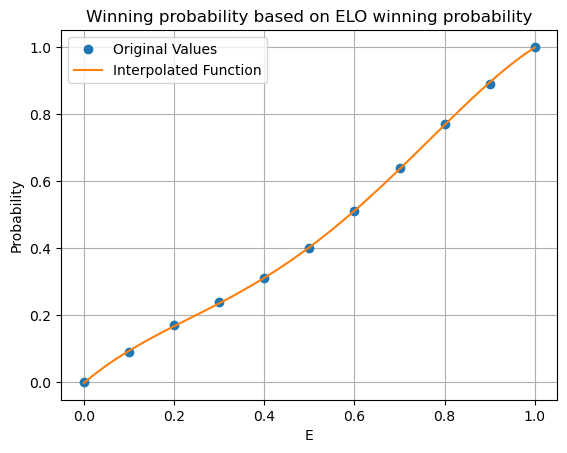

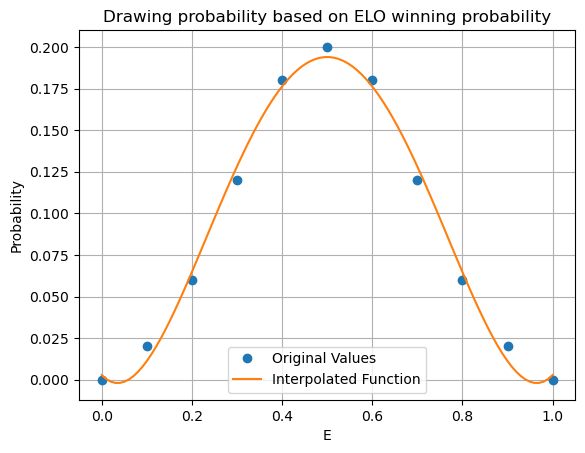

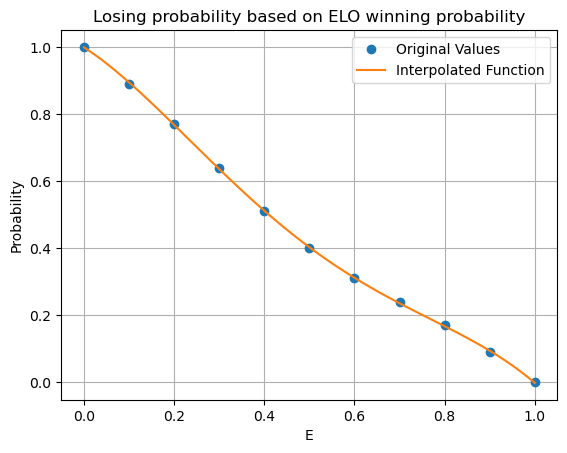

In [14]:
def plot_interpolation(x_values, y_values, interp_x_values, interp_y_values, title):
    """
    Plot the original values and the interpolated function.
    
    Parameters:
    x_values (list or array): List of original x values.
    y_values (list or array): List of original y values.
    interp_x_values (array): Interpolated x values.
    interp_y_values (array): Interpolated y values.
    """
    plt.plot(x_values, y_values, 'o', label='Original Values')
    plt.plot(interp_x_values, interp_y_values, '-', label='Interpolated Function')
    plt.xlabel('E')
    plt.ylabel('Probability')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_win(interp_x_values)
plot_interpolation(Es, win_data, interp_x_values, interp_y_values, "Winning probability based on ELO winning probability")

interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_draw(interp_x_values)
plot_interpolation(Es, draw_data, interp_x_values, interp_y_values, "Drawing probability based on ELO winning probability")

interp_x_values = np.linspace(min(Es), max(Es), 100)
interp_y_values = p_loss(interp_x_values)
plot_interpolation(Es, loss_data, interp_x_values, interp_y_values, "Losing probability based on ELO winning probability")


I m allowing myself a few approximations here, because the sum of probabilities is only "roughly" equal to 1 (and also the drawing interpolation can give negative probabilities, but we will just assume they are 0 in the method proposed right after). While statisticians are probably dying at this point, I am pretty sure this is enough for our project, as long as the game resolution accounts for this. I will now write a function that given two ELO ratings, returns whether the outcome is a win, a draw or a loss for player A. For this I ll randomly generate a number between 0 and 1. If that number is lower or equal than the losing probability, then player A will have lost. If not and the number is lower or equal than the losing + drawing probability, then the result is a draw. Otherwise, player A will have won. 

We will return 1 for a loss, 2 for a draw, and 3 for a win

In [15]:
from numpy import random
def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    int: 1, 2 or 3 respectively if player A lost, drew or won
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    if roll <= p_loss(prob_a):
        return 1
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        return 2
    else:
        return 3
    
    


As always let's check that the outcome is what we expect somehow

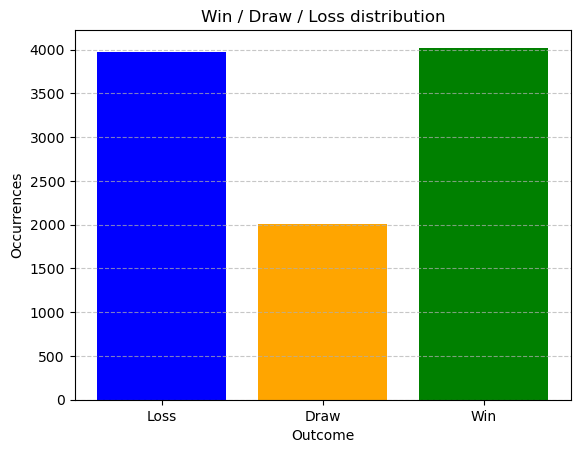

In [16]:
int_list = [play_match(1500, 1500) for _ in range (10000)]
occurrences = [int_list.count(1), int_list.count(2), int_list.count(3)]
    
# Integer labels
integers = ["Loss", "Draw", "Win"]
    
# Plotting
plt.bar(integers, occurrences, color=['blue', 'orange', 'green'])
plt.xlabel('Outcome')
plt.ylabel('Occurrences')
plt.title('Win / Draw / Loss distribution')
plt.xticks(integers)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### How big is a win / loss ?
Depending on the scoring system, a big win or loss has a different meaning in terms of KP / VP etc. So for now, we will simply attribute a score between 0 and 1 that says how "good" was the win/ the draw / the loss. A score of 1 means that the player should score the maximum number of points while a score or 0 means that the victory is the minimum possible. In the outcome, there will be one such number per player as for instance in the Northern Kings scoring system you can lose but kill most of the opponent army. These two numbers will later be interpreted by the scoring system to output a viable outcome.

I chose to link the probability of a "big" win to the actual probability of winning, by centering the distribution of the sample around it. For instance if you have a probability of winning of 80% the winning score is likely to be around 0.8, although a score of 0 remains possible but less likely. Let us reimplement the ```play_match``` function accordingly. Instead of outputting only a result, it also outputs 2 additional numbers who represents the score of each player

In [18]:
from numpy import random

def biased_draw(mean, std_dev = 0.1):
    # Rejection sampling: much faster than creating a truncnorm object each time
    while True:
        x = np.random.normal(mean, std_dev)
        if 0.0 <= x <= 1.0:
            return x


def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    a triplet:
        int: 1, 2 or 3 respectively if player A lost, drew or won
        float: a [0,1] float indicative of how many points should the player A receive 
        float: a [0,1] float indicative of how many points should the player B receive 
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    outcome_number = -1 
    outcome_rate_a = -1.;
    outcome_rate_b = -1.;
    if roll <= p_loss(prob_a):
        outcome_number = 1 #loss        
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        outcome_number = 2 #draw
    else:
        outcome_number = 3 #win
    outcome_rate_a = biased_draw(p_win(prob_a));
    outcome_rate_b = biased_draw(p_win(1.-prob_a));
    return [outcome_number, outcome_rate_a, outcome_rate_b]
    

Let's just check that this works. Let's have two players with a ELO rating difference of about 240, such that  player A has about 73% chances of winning with our continuous probability function. Let's have them play N times and check that:
+ overall player A wins 73% of the time
+ Whether he wins, draws or loses, the score is centered around 0.77 
+ Player B's score is centered around 0.23

win_probability(A) = 0.728
loss_probability(B) = 0.188
Win rate  : 72.7% 
Draw rate : 8.5%
Loss rate : 18.8%


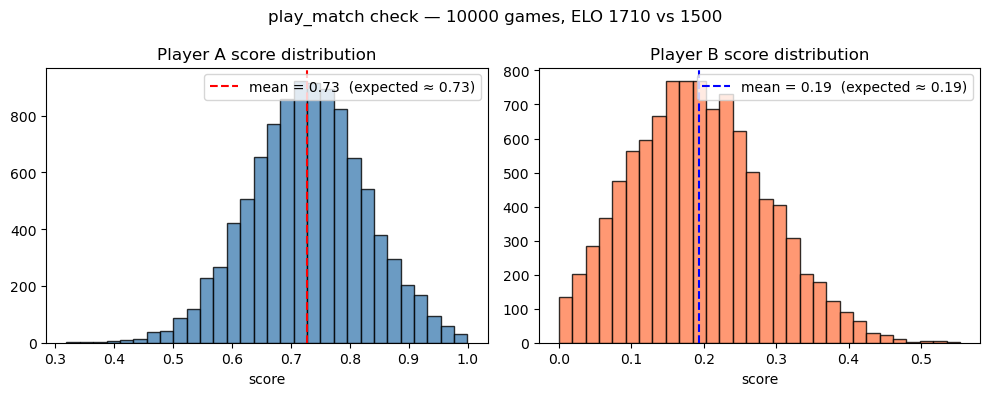

In [19]:
N = 10000
# 1710 vs 1500 gives win_probability ≈ 0.770
ra, rb = 1710, 1500
print(f"win_probability(A) = {p_win(win_probability(ra, rb)):.3f}")
print(f"loss_probability(B) = {p_loss(win_probability(ra, rb)):.3f}")

results = [play_match(ra, rb) for _ in range(N)]
wins  = [r for r in results if r[0] == 3]
draws = [r for r in results if r[0] == 2]
losses= [r for r in results if r[0] == 1]

print(f"Win rate  : {len(wins)/N*100:.1f}% ")
print(f"Draw rate : {len(draws)/N*100:.1f}%")
print(f"Loss rate : {len(losses)/N*100:.1f}%")

# Score distributions
import numpy as np
import matplotlib.pyplot as plt

scores_a = [r[1] for r in results]
scores_b = [r[2] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(scores_a, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(np.mean(scores_a), color='red', linestyle='--',
                label=f'mean = {np.mean(scores_a):.2f}  (expected ≈ 0.73)')
axes[0].set_title('Player A score distribution')
axes[0].set_xlabel('score'); axes[0].legend()

axes[1].hist(scores_b, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(np.mean(scores_b), color='blue', linestyle='--',
                label=f'mean = {np.mean(scores_b):.2f}  (expected ≈ 0.19)')
axes[1].set_title('Player B score distribution')
axes[1].set_xlabel('score'); axes[1].legend()

plt.suptitle(f'play_match check — {N} games, ELO {ra} vs {rb}')
plt.tight_layout()
plt.show()


After all this we now have a single function ```play_match``` that simulates a match between two players based on their ELO score.


## Playing a KOW tournament
We now have a mean of determining who wins. However there are other things that we need to consider if we want to compare scoring systems.

First, we need to compare the systems based on the same outcome for all  possible encounters (which is a problem because the matches played will not be the same depending on the systems).


Secondly, victory / loss / draw is not sufficient as we also need the kill points and the scenario points in most scoring systems. Other criteria might be considered but they are not relevant here in general.

### Generating encounters data
Depending on the system implemented, given the same outcomes different players will play against each other in a tournament. When comparing the system, to make sure that the same outcome is considered we will first simulate all the games possible (ie each player will play each other player). We will actually do this 5 times just to make sure that in the case players play several times against each other we also have these outcomes. (NB: the number of times players encounter each other is also a criteria for evaluating a scoring system). Given all the possible encounters outcome, we will then be able to apply each scoring system to the same data and evaluate the outcome of the tournament.

From now on, each player is identified by its index in the ELO ratings list, between 0 and 31


In [20]:
#we will store all the data into a list of list

def play(elo, opponents):
    return [[play_match(elo, elo_opponent) for _ in range(5)] for elo_opponent in opponents]

def tournament_data(elo_ratings):
    return [play(elo_ratings[i],elo_ratings[i+1:]) for i in range(len(elo_ratings)-1)]
    

#Uncomment the following lines to generate the tournament data. Note that it will take a while to run, as it simulates 5 matches for each pair of players in a 32 player tournament.

#elo_ratings = generate_normal_elo_ratings(N_PLAYERS)
#tournament_matches = tournament_data(elo_ratings)



To retrieve the outcome of a specific match we can write the following function. The ```remove_encounter``` parameter is used to remove the instance of the match and return a new outcome if players are to meet again.


In [21]:
def rev(num):
    if num == 1:
        return 3
    elif num == 3:
        return 1
    return 2

#return outcomes from player A perspective
def match_result(tournament_matches, playerAIndex, playerBIndex, remove_encounter=False):
    minIdx = min(playerAIndex, playerBIndex);
    maxIdx = max(playerAIndex, playerBIndex);
    outcome = tournament_matches[minIdx][maxIdx-1-minIdx][0]
    if playerAIndex > playerBIndex: #reverse outcomes
        outcome =[rev(outcome[0]),outcome[2], outcome[1]]
    if remove_encounter:
        tournament_matches[minIdx][maxIdx-1-minIdx][:] = tournament_matches[minIdx][maxIdx-1-minIdx][1:]
    return outcome        


## "Unrolling" a tournament
A tournament consists in the following steps:

1. randomly assign opponents
2. play all the games for the current round
3. rank the players according to their current score
4. If all the games have been played, go back to step 2. If not, the rank obtained is the final ranking

In our case, step 1 is already solved. Since we randomly assign profiles to the player, we can simply assign matches by progressing towards the list of profiles. We will need to add more information on the player profile though: an Id and a current score. We will also add a history of their encounters as an helper.




In [22]:
class Player:
    def __init__(self, idx, elo):
        self.idx = idx
        self.elo = elo
        self.score = 0
        self.resulttrack = []
        self.opponenttrack = []
        self.track = []
    def __str__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"
    def __repr__(self):
        return f"Player {self.idx}: Elo={self.elo}, Score={self.score}\n\t, Track{self.track}"

Step 2 is just a matter of retrieving the outcomes which we computed before.

Step 3 is the **ranking step** — how players are sorted between rounds determines who plays whom next, and the final ranking. We implement several ranking strategies:

- **`score`**: pure cumulative score (SP + KP), used by Northern Kings and Black Jack
- **`naive`**: wins → draws → score (simple win-count priority)
- **`wdl_sos`**: wins → draws → **Strength of Schedule** → score — a tiebreaker borrowed from chess
- **`wt_flat_sos`**: wins → draws → flat weighted wins → SOS → score

We detail the scoring systems in the [scoring section](#scoring). Let's discuss briefly the notion of Strength of Schedule here.


### Strength of Schedule (SOS)
<a id="sos"></a>
The **Strength of Schedule** (also known as the *Buchholz score* in chess) is defined after round $r$ as:

$$SOS_i^{(r)} = \sum_{k=1}^{r} S_{o_{i,k}}^{(r)}$$

where $S_{o_{i,k}}^{(r)}$ is the current cumulative win/draw score of the opponent player $i$ faced in round $k$ (recalculated after every round). The idea is simple: beating strong opponents counts for more than beating weak ones. Here the score is: wins × 100 + draws × 10.

### Weighted wins

We also test **weighted wins** as a tiebreaker: each round is assigned a weight and the score sums the weights for rounds won (half for draws, zero for losses). We tested several profiles — early-heavy `[6,5,4,3,2,1]`, late-heavy `[1,2,3,4,5,6]`, skip round 1 — and found that **flat weights** `[1,1,1,1,1,1]` combined with SOS give the best overall results.

### Win streaks

We also experiment with rewarding win streaks to try to compensate for submarining.


### Hybrid approach: separate pairing and ranking

We can also use **one system for pairing** (deciding who plays whom) and **another for the final ranking**. For instance, we can use Northern Kings for pairing before switching to a WDL+SOS for a final ranking.

The `play_tournament` function supports this via `ranking_mode` (used during the tournament for pairing) and `final_ranking_mode` (used only for the final standings).

We can thus write a `play_tournament` function that performs all steps given a scoring function and ranking mode.


### Testing pool for early rounds:
We also tested a format that was used in Warhammer in France, where the first X games were played in pool (everyone plays everyone), before proceeding as usual for the remaining games.

In [27]:
# TODO REMOVE

import copy

# ── Win/draw counters (used by sort_players, metrics, and SOS) ───────────────
def num_win(player):
    return sum(1 for r in player.resulttrack if r == 3)

def num_draw(player):
    return sum(1 for r in player.resulttrack if r == 2)

def num_win_draw(player):
    return 100 * num_win(player) + 10 * num_draw(player)

# Aliases used inside sort_players (keeps kow.ipynb naming)
num_wins  = num_win
num_draws = num_draw

# ── Weighted-wins configurations ─────────────────────────────────────────────
WEIGHT_CONFIGS = {
    "early":     [6, 5, 4, 3, 2, 1],
    "skip_r1":   [0, 5, 4, 3, 2, 1],
    "flat_r1":   [1, 5, 4, 3, 2, 1],
    "late":      [1, 2, 3, 4, 5, 6],
    "flat":      [1, 1, 1, 1, 1, 1],
    "skip_late": [0, 2, 3, 4, 5, 6],
}

def make_weighted_fn(weights):
    """Return a weighted-wins function using the given per-round weights."""
    def fn(player):
        score = 0
        for r, res in enumerate(player.resulttrack):
            w = weights[r] if r < len(weights) else 0
            if res == 3:
                score += w
            elif res == 2:
                score += w * 0.5
        return score
    return fn

WEIGHTED_FNS = {name: make_weighted_fn(w) for name, w in WEIGHT_CONFIGS.items()}

# ── Strength of Schedule (Buchholz) ──────────────────────────────────────────
def compute_sos(player, players_by_idx):
    """Buchholz score: sum of (wins*100 + draws*10) of all opponents faced so far."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack)

def compute_sos_r2(player, players_by_idx):
    """SOS excluding round 1 (random pairing). Counts opponents from round 2 onwards."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack[1:])

# ── Streak and round-weighted helpers ────────────────────────────────────────
def streak_bonus(player):
    streak = 0
    for res in player.resulttrack:
        if res == 3:
            streak += 1
        else:
            break
    return max(0, streak - 1)

def streak_metric(player):
    return num_win_draw(player) + streak_bonus(player)

def round_weighted_wins(player):
    return WEIGHTED_FNS["early"](player)

# ── Ranking step ─────────────────────────────────────────────────────────────
def sort_players(current_ranking, ranking_mode):
    """Sort players according to the ranking mode."""
    if ranking_mode.startswith("wt_"):
        suffix = ranking_mode[3:]
        use_sos = suffix.endswith("_sos")
        config_name = suffix[:-4] if use_sos else suffix
        wfn = WEIGHTED_FNS[config_name]
        if use_sos:
            players_by_idx = {p.idx: p for p in current_ranking}
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -compute_sos(p, players_by_idx), -p.score))
        else:
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -p.score))
    elif ranking_mode == "streak":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -streak_metric(p)))
    elif ranking_mode == "streak_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "streak_sos_r2":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos_r2(p, players_by_idx)))
    elif ranking_mode == "weighted":
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p)))
    elif ranking_mode == "weighted_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p), -compute_sos(p, players_by_idx)))
    elif ranking_mode == "naive":
        return sorted(current_ranking, key=lambda p: (-num_wins(p), -num_draws(p), -p.score))
    elif ranking_mode == "wdl_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -compute_sos(p, players_by_idx), -p.score))
    else:  # "score"
        return sorted(current_ranking, key=lambda p: -p.score)

# ── Tournament engine (Swiss) ─────────────────────────────────────────────────
def play_tournament(player_elos, matches_results, score_function,
                    ranking_mode="score", final_ranking_mode=None, collect_history=True):
    """Play a Swiss tournament. ranking_mode is used for pairing during the
    tournament; final_ranking_mode (if set) is used only for the final standings."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    players = [Player(i, elo) for (i, elo) in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)
    current_ranking = copy.deepcopy(players)
    ranking_history = []
    def play_round(current_round):
        nonlocal ranking_history, current_ranking, players, current_matches
        if current_round == NUM_ROUNDS:
            current_ranking = sort_players(current_ranking, final_ranking_mode)
            return current_ranking
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]
        scores = [score_function(outcome, current_round) for outcome in round_outcomes]
        for i, score in enumerate(scores):
            current_ranking[2*i].score   += score[0]
            current_ranking[2*i+1].score += score[1]
            current_ranking[2*i].resulttrack   += [round_outcomes[i][0]]
            current_ranking[2*i+1].resulttrack += [rev(round_outcomes[i][0])]
            current_ranking[2*i].opponenttrack   += [current_ranking[2*i+1].idx]
            current_ranking[2*i+1].opponenttrack += [current_ranking[2*i  ].idx]
            if collect_history:
                current_ranking[2*i].track   += ["player " + str(current_ranking[2*i+1].idx) + ": " + str(round_outcomes[i][0])]
                current_ranking[2*i+1].track += ["player " + str(current_ranking[2*i  ].idx) + ": " + str(rev(round_outcomes[i][0]))]
        current_ranking = sort_players(current_ranking, ranking_mode)
        if collect_history:
            ranking_history += [copy.deepcopy(current_ranking)]
        return play_round(current_round + 1)
    return play_round(0), ranking_history

# ── Tournament engine (Pool + Swiss) ─────────────────────────────────────────
def play_pool_tournament(player_elos, matches_results, score_function,
                         ranking_mode="score", final_ranking_mode=None):
    """3 rounds of pool play (groups of 4, full round-robin) then 2 Swiss rounds."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode
    n = len(player_elos)
    players = [Player(i, elo) for i, elo in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)
    indices = list(range(n))
    import numpy as np
    np.random.shuffle(indices)
    pools = [indices[i:i+4] for i in range(0, n, 4)]
    rr_pairings = [[(0, 1), (2, 3)], [(0, 2), (1, 3)], [(0, 3), (1, 2)]]
    for rnd, pairs in enumerate(rr_pairings):
        for pool in pools:
            for a_local, b_local in pairs:
                pa = players[pool[a_local]]
                pb = players[pool[b_local]]
                outcome = match_result(current_matches, pa.idx, pb.idx, remove_encounter=False)
                sc = score_function(outcome, rnd)
                pa.score += sc[0]; pb.score += sc[1]
                pa.resulttrack.append(outcome[0]);  pb.resulttrack.append(rev(outcome[0]))
                pa.opponenttrack.append(pb.idx);    pb.opponenttrack.append(pa.idx)
    current_ranking = sort_players(list(players), ranking_mode)
    for rnd in range(3, 5):
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]
        scores_list = [score_function(outcome, rnd) for outcome in round_outcomes]
        for i, sc in enumerate(scores_list):
            current_ranking[2*i].score   += sc[0]; current_ranking[2*i+1].score   += sc[1]
            current_ranking[2*i].resulttrack.append(round_outcomes[i][0])
            current_ranking[2*i+1].resulttrack.append(rev(round_outcomes[i][0]))
            current_ranking[2*i].opponenttrack.append(current_ranking[2*i+1].idx)
            current_ranking[2*i+1].opponenttrack.append(current_ranking[2*i].idx)
        current_ranking = sort_players(current_ranking, ranking_mode)
    current_ranking = sort_players(current_ranking, final_ranking_mode)
    return current_ranking, []

print("Tournament engine ready (Swiss + Pool).")


Tournament engine ready (Swiss + Pool).


In [29]:
import copy

# ------------------------------------------------------------------------------
# Win/Draw/Loss helpers
# Used by:
# - ranking logic
# - metrics
# - Strength of Schedule (SOS)
# ------------------------------------------------------------------------------

def num_win(player):
    return sum(1 for r in player.resulttrack if r == 3)

def num_draw(player):
    return sum(1 for r in player.resulttrack if r == 2)

def num_win_draw(player):
    # Compact WDL score for tie-break logic:
    # 1 win = 100, 1 draw = 10
    return 100 * num_win(player) + 10 * num_draw(player)

# Legacy aliases (keeps compatibility with older naming)
num_wins = num_win
num_draws = num_draw


# ------------------------------------------------------------------------------
# Weighted-win configurations
# ------------------------------------------------------------------------------

WEIGHT_CONFIGS = {
    "early":     [6, 5, 4, 3, 2, 1],  # early rounds weighted more
    "skip_r1":   [0, 5, 4, 3, 2, 1],  # ignore round 1
    "flat_r1":   [1, 5, 4, 3, 2, 1],  # light weight on round 1
    "late":      [1, 2, 3, 4, 5, 6],  # late rounds weighted more
    "flat":      [1, 1, 1, 1, 1, 1],  # all rounds equal
    "skip_late": [0, 2, 3, 4, 5, 6],  # variant with round 1 ignored
}

def make_weighted_fn(weights):
    """Return a weighted-wins function for the provided round weights."""
    def fn(player):
        score = 0
        for r, res in enumerate(player.resulttrack):
            w = weights[r] if r < len(weights) else 0
            if res == 3:
                score += w
            elif res == 2:
                score += w * 0.5
        return score
    return fn

WEIGHTED_FNS = {name: make_weighted_fn(w) for name, w in WEIGHT_CONFIGS.items()}


# ------------------------------------------------------------------------------
# Strength of Schedule (Buchholz)
# ------------------------------------------------------------------------------

def compute_sos(player, players_by_idx):
    """Standard SOS: sum of WDL scores of all opponents played so far."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack)

def compute_sos_r2(player, players_by_idx):
    """SOS excluding round 1 (which is random pairing)."""
    return sum(num_win_draw(players_by_idx[opp_idx]) for opp_idx in player.opponenttrack[1:])


# ------------------------------------------------------------------------------
# Streak helpers
# ------------------------------------------------------------------------------

def streak_bonus(player):
    # Counts consecutive wins from round 1, then removes 1 to avoid over-rewarding
    # a single opening win.
    streak = 0
    for res in player.resulttrack:
        if res == 3:
            streak += 1
        else:
            break
    return max(0, streak - 1)

def streak_metric(player):
    return num_win_draw(player) + streak_bonus(player)

def round_weighted_wins(player):
    return WEIGHTED_FNS["early"](player)


# ------------------------------------------------------------------------------
# Ranking logic
# ------------------------------------------------------------------------------

def sort_players(current_ranking, ranking_mode):
    """Sort players according to the selected ranking mode."""
    if ranking_mode.startswith("wt_"):
        suffix = ranking_mode[3:]
        use_sos = suffix.endswith("_sos")
        config_name = suffix[:-4] if use_sos else suffix
        wfn = WEIGHTED_FNS[config_name]
        if use_sos:
            players_by_idx = {p.idx: p for p in current_ranking}
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -compute_sos(p, players_by_idx), -p.score))
        else:
            return sorted(current_ranking, key=lambda p: (
                -num_wins(p), -num_draws(p), -wfn(p), -p.score))

    elif ranking_mode == "streak":
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_metric(p)))

    elif ranking_mode == "streak_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos(p, players_by_idx)))

    elif ranking_mode == "streak_sos_r2":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -streak_bonus(p), -compute_sos_r2(p, players_by_idx)))

    elif ranking_mode == "weighted":
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p)))

    elif ranking_mode == "weighted_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -round_weighted_wins(p), -compute_sos(p, players_by_idx)))

    elif ranking_mode == "naive":
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -p.score))

    elif ranking_mode == "wdl_sos":
        players_by_idx = {p.idx: p for p in current_ranking}
        return sorted(current_ranking, key=lambda p: (
            -num_wins(p), -num_draws(p), -compute_sos(p, players_by_idx), -p.score))

    else:  # "score"
        return sorted(current_ranking, key=lambda p: -p.score)


# ------------------------------------------------------------------------------
# Swiss tournament engine
# ------------------------------------------------------------------------------

def play_tournament(player_elos, matches_results, score_function,
                    ranking_mode="score", final_ranking_mode=None, collect_history=True):
    """
    Play a Swiss tournament.
    - ranking_mode: used after each round (affects next pairings)
    - final_ranking_mode: used only for the final standings
    """
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode

    players = [Player(i, elo) for (i, elo) in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)
    current_ranking = copy.deepcopy(players)
    ranking_history = []

    def play_round(current_round):
        nonlocal ranking_history, current_ranking, players, current_matches

        if current_round == NUM_ROUNDS:
            current_ranking = sort_players(current_ranking, final_ranking_mode)
            return current_ranking

        # Pairing: (0 vs 1), (2 vs 3), ...
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]

        # Convert match outcomes into points using the selected scoring function
        scores = [score_function(outcome, current_round) for outcome in round_outcomes]

        # Update each player's state
        for i, score in enumerate(scores):
            current_ranking[2*i].score   += score[0]
            current_ranking[2*i+1].score += score[1]

            current_ranking[2*i].resulttrack   += [round_outcomes[i][0]]
            current_ranking[2*i+1].resulttrack += [rev(round_outcomes[i][0])]

            current_ranking[2*i].opponenttrack   += [current_ranking[2*i+1].idx]
            current_ranking[2*i+1].opponenttrack += [current_ranking[2*i].idx]

            if collect_history:
                current_ranking[2*i].track += [
                    "player " + str(current_ranking[2*i+1].idx) + ": " + str(round_outcomes[i][0])]
                current_ranking[2*i+1].track += [
                    "player " + str(current_ranking[2*i].idx) + ": " + str(rev(round_outcomes[i][0]))]

        # Re-rank for next Swiss round
        current_ranking = sort_players(current_ranking, ranking_mode)

        if collect_history:
            ranking_history += [copy.deepcopy(current_ranking)]

        return play_round(current_round + 1)

    return play_round(0), ranking_history


# ------------------------------------------------------------------------------
# Pool + Swiss engine
# 3 pool rounds (groups of 4, round-robin) then 2 Swiss rounds
# ------------------------------------------------------------------------------

def play_pool_tournament(player_elos, matches_results, score_function,
                         ranking_mode="score", final_ranking_mode=None):
    """3 rounds of pool play (groups of 4, full round-robin) then 2 Swiss rounds."""
    if final_ranking_mode is None:
        final_ranking_mode = ranking_mode

    n = len(player_elos)
    players = [Player(i, elo) for i, elo in enumerate(player_elos)]
    current_matches = copy.deepcopy(matches_results)

    indices = list(range(n))
    import numpy as np
    np.random.shuffle(indices)
    pools = [indices[i:i+4] for i in range(0, n, 4)]

    # Round-robin schedule for 4-player pools
    rr_pairings = [[(0, 1), (2, 3)], [(0, 2), (1, 3)], [(0, 3), (1, 2)]]

    # Pool phase (rounds 0,1,2)
    for rnd, pairs in enumerate(rr_pairings):
        for pool in pools:
            for a_local, b_local in pairs:
                pa = players[pool[a_local]]
                pb = players[pool[b_local]]

                outcome = match_result(current_matches, pa.idx, pb.idx, remove_encounter=False)
                sc = score_function(outcome, rnd)

                pa.score += sc[0]
                pb.score += sc[1]
                pa.resulttrack.append(outcome[0])
                pb.resulttrack.append(rev(outcome[0]))
                pa.opponenttrack.append(pb.idx)
                pb.opponenttrack.append(pa.idx)

    current_ranking = sort_players(list(players), ranking_mode)

    # Swiss phase (rounds 3,4)
    for rnd in range(3, 5):
        round_outcomes = [
            match_result(current_matches, current_ranking[i].idx, current_ranking[i+1].idx,
                         remove_encounter=False)
            for i in range(0, len(current_ranking), 2)
        ]
        scores_list = [score_function(outcome, rnd) for outcome in round_outcomes]

        for i, sc in enumerate(scores_list):
            current_ranking[2*i].score   += sc[0]
            current_ranking[2*i+1].score += sc[1]
            current_ranking[2*i].resulttrack.append(round_outcomes[i][0])
            current_ranking[2*i+1].resulttrack.append(rev(round_outcomes[i][0]))
            current_ranking[2*i].opponenttrack.append(current_ranking[2*i+1].idx)
            current_ranking[2*i+1].opponenttrack.append(current_ranking[2*i].idx)

        current_ranking = sort_players(current_ranking, ranking_mode)

    current_ranking = sort_players(current_ranking, final_ranking_mode)
    return current_ranking, []

print("Tournament engine ready (Swiss + Pool).")

Tournament engine ready (Swiss + Pool).


Let's test our tournament function with a naive scoring function that simply returns 10 times the outcome number (1, 2 or 3) + the "goodness" of the result

In [30]:
#if data exists on the disk load it otherwise generate a new file
#we can save the data here:
import pickle
import os


def generate_data(reset_data=False, file_name="tournament_data.pkl"):
    data = None
    if os.path.exists(file_name) and not reset_data:  # Check if the file exists
        with open(file_name, "rb") as file:
            data = pickle.load(file)
            #print("Data loaded from file.")
    else:        
        # If file not found, call gen() and save the generated data to the file
        player_elos = generate_normal_elo_ratings(N_PLAYERS);
        matches_results = tournament_data(player_elos)        
        data = [player_elos, matches_results]
        with open(file_name, "wb") as file:
            pickle.dump(data, file)
    return data


In [37]:
def naive_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    return [10*res1 + result_triplet[1], 10*res2 + result_triplet[2]]


MIN_ELO = 1300
MAX_ELO = 2200
AVG_ELO = 1400

data = generate_data(False)
final_rank, ranking_history = play_tournament(data[0], data[1], naive_score)

We can see the ranking in text form but it is not super readable

In [38]:
final_rank

[Player 8: Elo=2092.954463559392, Score=153.69508668036394
 	, Track['player 9: 3', 'player 6: 3', 'player 5: 3', 'player 28: 3', 'player 21: 3'],
 Player 0: Elo=2056.4315837896006, Score=133.22720163267428
 	, Track['player 1: 3', 'player 28: 1', 'player 6: 3', 'player 12: 3', 'player 5: 3'],
 Player 28: Elo=2022.8901336441045, Score=133.00711084171658
 	, Track['player 29: 3', 'player 0: 3', 'player 12: 3', 'player 8: 1', 'player 9: 3'],
 Player 21: Elo=1805.0744248562219, Score=132.5818527943342
 	, Track['player 20: 3', 'player 17: 3', 'player 19: 3', 'player 30: 3', 'player 8: 1'],
 Player 30: Elo=1564.859433711526, Score=131.75818414292513
 	, Track['player 31: 3', 'player 24: 3', 'player 27: 3', 'player 21: 1', 'player 11: 3'],
 Player 25: Elo=1808.4483247906946, Score=123.9422321823624
 	, Track['player 24: 1', 'player 31: 2', 'player 23: 3', 'player 27: 3', 'player 19: 3'],
 Player 26: Elo=1307.19153606366, Score=120.82618965431283
 	, Track['player 27: 2', 'player 3: 3', 'pla

Let's add some code to visualise the output of the tournament

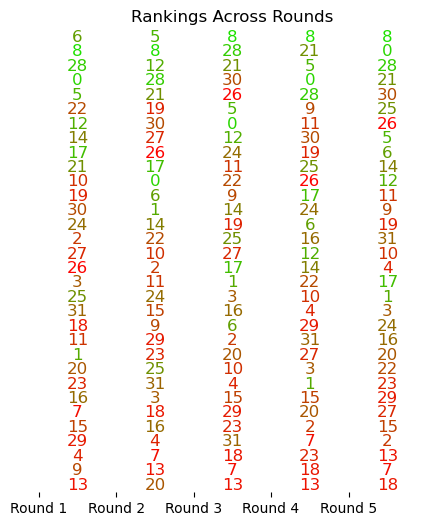

In [39]:
import matplotlib.pyplot as plt

def elo_to_color(elo):
    """Convert an Elo rating to a color in the gradient from red to green."""
    # Normalize Elo between 0 and 1
    norm_elo = (elo - MIN_ELO) / (MAX_ELO - MIN_ELO)
    # Ensure norm_elo is between 0 and 1
    norm_elo = np.clip(norm_elo, 0, 1)
    # Create a color from red (low Elo) to green (high Elo)
    return (1 - norm_elo, norm_elo, 0)  # RGB format

def plot_rankings(rankings):
    num_rounds = len(rankings)
    num_items = len(rankings[0])
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(num_rounds, 6))  # Adjust width for number of rounds
    
    # Plot rankings for each round
    for round_idx, round_rankings in enumerate(rankings):
        for rank_idx, player in enumerate(round_rankings):
            # Align the rank text based on the ranking position
            ax.text(round_idx + 0.5, rank_idx + 0.5, str(player.idx), 
                    ha='center', va='center', fontsize=12, color = elo_to_color(player.elo))

    # Formatting the plot
    ax.set_xlim(0, num_rounds)
    ax.set_ylim(0, num_items)
    ax.set_xticks(range(num_rounds))
    ax.set_xticklabels([f"Round {i + 1}" for i in range(num_rounds)], fontsize=10)
    ax.set_yticks(range(1, num_items + 1))
    ax.invert_yaxis()  # Invert y-axis to have rank 1 at the top
    ax.set_title(f"Rankings Across Rounds")
    
    # Remove unnecessary axes for a cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_visible(False)
    
    plt.show()

plot_rankings(ranking_history)


The greener the stronger the player is. Each column represents the standings after the next round, and each plair is playing the other


In [40]:
ranking_history[-1][4]

Player 30: Elo=1564.859433711526, Score=131.75818414292513
	, Track['player 31: 3', 'player 24: 3', 'player 27: 3', 'player 21: 1', 'player 11: 3']

Cool! Now, onto implementing the different scoring systems.
<a id="scoring"></a>
## Scoring systems
### Scoring strategy
What I choose to do is to first compute the winner score for each scenario, determine their point based on "how good" they performed. Then I compute the loser score. For a draw, I proceed similarly starting with the "highest" drawer.

The winner / best drawer score is given by his "normalised" score computed during the outcome, times the maximum score he can obtain (and shifted according to the minimum possible score), rounded up (down for the loser). 

### Northern Kings scoring system
This is by far the hardest system to implement since the scoring depends on the scenario... I ll just play the scenarios in the book order, and repeat the last one in case of additional rounds. For each scenario I ll mark the min / max points scored by the winner / loser / draw. Acknowledging that the maximum number of scenario points is 5:
* Pillage  (1/7 0/3 0/3)
* Loot     (2/6 0/2 0/2)
* Push     (1/6 0/3 0/4)
* Dominate (1/7 0/6 0/5)
* Invade   (1/7 0/6 0/5)


* Win / Draw / loss basic scores: 15 / 10 / 5

* Then the KP are from 0 to 5


In [42]:
from math import ceil, floor

NK_scores= [
    [1,7,0,3,0,3],
    [2,6,0,2,0,2],
    [1,6,0,3,0,4],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
    [1,7,0,6,0,5],
]

def result_sp_win(player_score,round_number):    
    return ceil(float(NK_scores[round_number][0] + (NK_scores[round_number][1] - NK_scores[round_number][0]) * player_score))

def result_sp_loss(player_score,round_number, winner_sp):
    return min(winner_sp-1,floor(float(NK_scores[round_number][4] + (NK_scores[round_number][5] - NK_scores[round_number][4]) * player_score)))

def result_draw_win(player_score,round_number):
    return ceil(float(NK_scores[round_number][2] + (NK_scores[round_number][3] - NK_scores[round_number][2]) * player_score))

def result_draw_loss(player_score,round_number, winner_sp):
    return winner_sp #necessary the same sp score


def final_score(res, sp_score, normalised_score):
    return res *5 + min(5,sp_score) + floor(float(normalised_score * 5)) 

def nk_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
    if (res1 == 2):
        if(result_triplet[1]>result_triplet[2]):
            normalised_score_win  = result_triplet[1]
            normalised_score_loss = result_triplet[2]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_win, normalised_score_win), final_score(res2, sp_loss, normalised_score_loss)] 
        else:
            normalised_score_win  = result_triplet[2]
            normalised_score_loss = result_triplet[1]
            sp_win   = result_draw_win (normalised_score_win, round_number)
            sp_loss  = result_draw_loss(normalised_score_loss,round_number, sp_win)
            return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)] 
    else:
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        sp_win   = result_sp_win (normalised_score_win, round_number)
        sp_loss  = result_sp_loss(normalised_score_loss,round_number, sp_win)
        return [final_score(res1, sp_loss, normalised_score_loss), final_score(res2, sp_win, normalised_score_win)]
            
        

Let's see how the same tournament goes under the NK ruling system

In [43]:
final_rank, ranking_history_NK = play_tournament(data[0], data[1], nk_score)

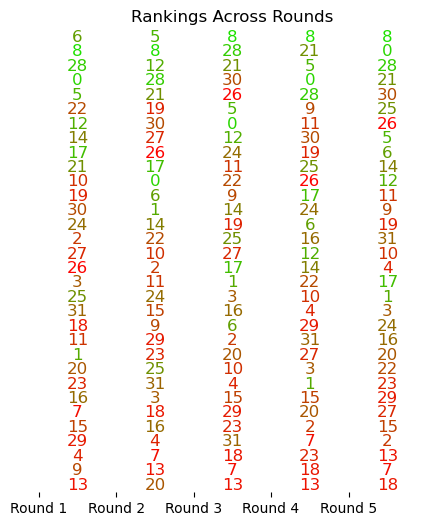

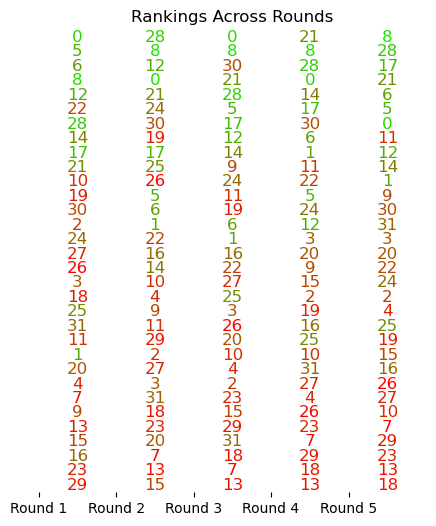

[Player 8: Elo=2092.954463559392, Score=153.69508668036394
 	, Track['player 9: 3', 'player 6: 3', 'player 5: 3', 'player 28: 3', 'player 21: 3'],
 Player 0: Elo=2056.4315837896006, Score=133.22720163267428
 	, Track['player 1: 3', 'player 28: 1', 'player 6: 3', 'player 12: 3', 'player 5: 3'],
 Player 28: Elo=2022.8901336441045, Score=133.00711084171658
 	, Track['player 29: 3', 'player 0: 3', 'player 12: 3', 'player 8: 1', 'player 9: 3'],
 Player 21: Elo=1805.0744248562219, Score=132.5818527943342
 	, Track['player 20: 3', 'player 17: 3', 'player 19: 3', 'player 30: 3', 'player 8: 1'],
 Player 30: Elo=1564.859433711526, Score=131.75818414292513
 	, Track['player 31: 3', 'player 24: 3', 'player 27: 3', 'player 21: 1', 'player 11: 3'],
 Player 25: Elo=1808.4483247906946, Score=123.9422321823624
 	, Track['player 24: 1', 'player 31: 2', 'player 23: 3', 'player 27: 3', 'player 19: 3'],
 Player 26: Elo=1307.19153606366, Score=120.82618965431283
 	, Track['player 27: 2', 'player 3: 3', 'pla

In [44]:
plot_rankings(ranking_history)
plot_rankings(ranking_history_NK)
ranking_history[-1][:]


### Black jack scoring system
In the black jack system you need to compare both scores to decide the performance of each player, both for scenario points and victory points. I ll compute the scenario points score of the winner as the difference between their normalised score and the normalised loser score times 4, rounded up (and at a minimum of 0). The loser then gets minus that score.
For the attrition, I ll just compute the difference between the normalised scores times 3, but this one can be negative. The loser gets minus the score (which can be positive).



In [45]:
import numpy as np


def result_sp_win_BJ(player1_score,player2_score):
    score1 = max(0, np.round((player1_score - player2_score) * 4))
    return score1, -score1


def result_sp_loss_BJ(player1_score,player2_score):
    score2, score1 = result_sp_win(player2_score, player1_score)
    return score1, score2


def result_sp_draw_BJ(player1_score,player2_score):
    return 0,0


def result_kp_BJ(player1_score,player2_score):
    score1 = np.round((player1_score- player2_score) * 3)
    return score1, -score1




def bj_score(result_triplet, round_number):
    res1 = result_triplet[0]
    res2 = rev(res1) 
    if(res1 == 3):
        normalised_score_win  = result_triplet[1]
        normalised_score_loss = result_triplet[2]
        score1_sp, score2_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score1_kp, score2_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    if(res1==1):        
        normalised_score_win  = result_triplet[2]
        normalised_score_loss = result_triplet[1]
        score2_sp, score1_sp = result_sp_win_BJ(normalised_score_win,normalised_score_loss)
        score2_kp, score1_kp = result_kp_BJ    (normalised_score_win,normalised_score_loss)        
        return [14+score1_sp+score1_kp, 7+score2_sp+score2_kp] 
    else:
        score1_kp, score2_kp = result_kp_BJ(result_triplet[1],result_triplet[2])    
        return [10+score1_kp, 10+score2_kp] 

In [46]:
final_rank, ranking_history_BK = play_tournament(data[0], data[1], bj_score)

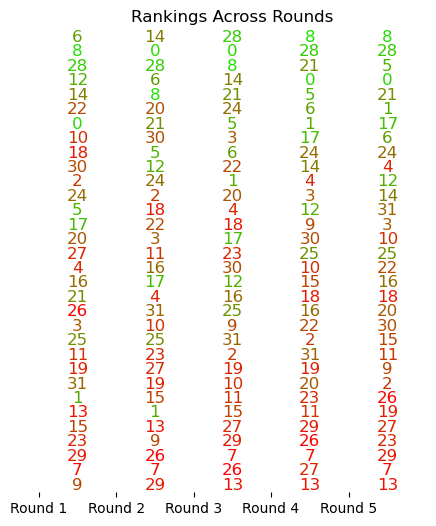

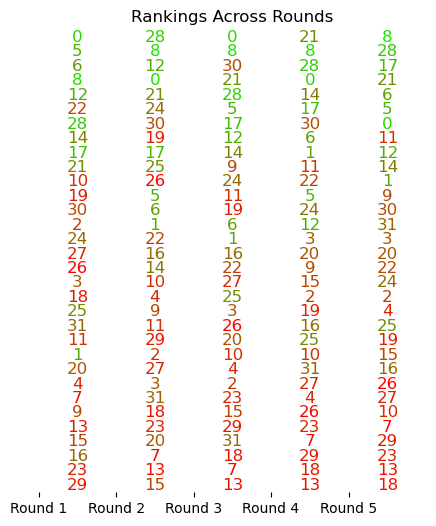

In [47]:
plot_rankings(ranking_history_BK)
plot_rankings(ranking_history_NK)

<a id="metrics"> </a>
## III. Evaluation criteria
There are many metrics that we can consider in general, but they are all more of less subjective.
One which is objective though is that, if we run a very large number of tournaments, the best players should overall trust the top positions. Let's play 1000 tournaments and measure, for each system, on average the "distance" between each player and their estimated positions. We'll use the [Kendall Tau](https://en.wikipedia.org/wiki/Kendall_rank_correlation_coefficient) to measure the distance. All metrics are normalised to the **[0, 1]** range: a value of 0 means perfect agreement and 1 means maximum disagreement.


###  ELO Distance
How aligned is the ranking with respect to the theoretical level of the players? 
I am not convinced this metric is so interesting as it is very theoretical and in kings of war the army pairings are quite important as well. We'll write it anyway and see what to conclude from it


In [49]:

from scipy.stats import kendalltau



def elodistance(tournament_ranking, top_n=None):
    elos = [player.elo for player in tournament_ranking]
    sortedelos = sorted(elos, reverse=True)
    if top_n is not None:
        sortedelos = sortedelos[:top_n]
        elos = elos[:top_n]
    tau, p_value = kendalltau(sortedelos, elos)
    return (1 - tau) / 2


### Metric: Number of wins
Let's check that the winner is the one with the most wins / draws

In [50]:
def winner_has_win(tournament_ranking):
    wins = [num_win_draw(player) for player in tournament_ranking]
    sortedwins = sorted(wins, reverse=True)
    tau, p_value = kendalltau(wins, sortedwins)
    return (1 - tau) / 2


### Metric: The Bigger the Better

Among players with the same number of wins and draws, does the ranking preserve the score they actually achieved during the tournament? We group players by identical W/D record and, within each group, check whether higher-ranked players also have a higher final tournament score. The cost is the fraction of discordant pairs inside those groups: 0 means perfect agreement, 1 means the ordering is fully inverted.

With this definition, the metric is no longer a direct proxy for "how dominant" a win was. Instead, it measures whether a system consistently uses the score it generated to separate players who have the same win/draw record.

In [ ]:
from collections import defaultdict

def bigger_the_better(tournament_ranking):
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        win_groups[wins].append((rank_pos, player))
    total_pairs = 0
    discordant = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, player_i = players[i]
                rank_j, player_j = players[j]
                total_pairs += 1
                # rank_i < rank_j means player_i is ranked higher
                # player_i.elo > player_j.elo means player_i is stronger
                if (rank_i < rank_j) != (player_i.elo > player_j.elo):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0

In [54]:
#TODO TEST 
from collections import defaultdict

def bigger_the_better(tournament_ranking):
    """
    Among players with the same W/D record, check whether higher-ranked players
    also have higher ACTUAL tournament score (player.score), not Elo proxy.
    Cost = fraction of discordant pairs (0 best, 1 worst).
    """
    wd_groups = defaultdict(list)

    for rank_pos, player in enumerate(tournament_ranking):
        key = (num_win(player), num_draw(player))   # same W/D bucket
        actual_score = player.score                 # score really achieved in event
        wd_groups[key].append((rank_pos, actual_score))

    total_pairs = 0
    discordant = 0

    for _, players in wd_groups.items():
        if len(players) < 2:
            continue

        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, score_i = players[i]
                rank_j, score_j = players[j]

                if score_i == score_j:
                    continue  # tie: no preference

                total_pairs += 1
                # rank_i < rank_j => i is ranked above j
                # score_i > score_j => i should be above j
                if (rank_i < rank_j) != (score_i > score_j):
                    discordant += 1

    return discordant / total_pairs if total_pairs > 0 else 0

### Metric: Submariners

Does the scoring system reward losing early? In Swiss-style systems, losing early means facing weaker opponents later, making it easier to accumulate wins. We build a reference ranking where players are sorted by wins (desc), then draws (desc), then a "late loss" score (sum of round indices where losses occurred — higher means losses came later). We then compute a Kendall tau between this reference and the actual tournament ranking. A cost of 0 means the system perfectly reflects the reference; 0.5 means random; higher values indicate the system rewards early losses.

In [55]:

def submariner_metric(tournament_ranking):
    # Build a reference ranking: wins desc, draws desc, late-loss score desc
    # Late-loss score = sum of round indices where player lost (higher = lost later = better)
    scores = []
    for player in tournament_ranking:
        wins = sum(1 for r in player.resulttrack if r == 3)
        draws = sum(1 for r in player.resulttrack if r == 2)
        loss_round_sum = sum(r for r, res in enumerate(player.resulttrack) if res == 1)
        score = wins * 10000 + draws * 100 + loss_round_sum
        scores.append(score)
    sorted_scores = sorted(scores, reverse=True)
    tau, _ = kendalltau(sorted_scores, scores)
    return (1 - tau) / 2

### Metric: Games Balance

Are players mostly playing opponents of similar strength? A good pairing system should match players with comparable Elo ratings as the tournament progresses. For each game played, we compute the absolute Elo difference between the two opponents, normalised by the maximum possible Elo gap in the tournament. The metric returns the average normalised Elo gap across all games. A cost of 0 means all games are perfectly balanced; 1 means every game is a maximum mismatch.

In [56]:
def games_balance(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    all_elos = list(elo_map.values())
    max_gap = max(all_elos) - min(all_elos)
    if max_gap == 0:
        return 0
    total_gap = 0
    total_games = 0
    for player in tournament_ranking:
        # Skip round 1 (index 0) since pairing is random
        for opp_idx in player.opponenttrack[1:]:
            total_gap += abs(player.elo - elo_map[opp_idx])
            total_games += 1
    # each game counted twice (once per player)
    return (total_gap / total_games) / max_gap if total_games > 0 else 0

### Metric: Replays

Do players face the same opponent multiple times during the tournament? In a 5-round, 32-player tournament there are enough players that ideally no one should play the same opponent twice. We count the total number of repeated pairings across all players (each repeat counted once), normalised by the total number of games. A cost of 0 means no replays at all; higher values indicate more repeat matchups.

In [57]:
def replays_metric(tournament_ranking):
    total_replays = 0
    total_games = 0
    for player in tournament_ranking:
        seen = set()
        for opp_idx in player.opponenttrack:
            total_games += 1
            if opp_idx in seen:
                total_replays += 1
            seen.add(opp_idx)
    # each game counted twice (once per player), same for replays
    return total_replays / total_games if total_games > 0 else 0

### Metric: Eat the Weak

Are strong players who happen to be paired against weaker opponents unfairly boosted in the final ranking? For each player we compute the average Elo of their opponents: a lower average means they faced weaker opposition. We then check, among players with the same win count, whether those who faced weaker opponents end up ranked higher. The cost is the fraction of discordant pairs where the player who faced weaker opponents is ranked above the one who faced stronger opponents. A value of 0 means no such advantage; higher values indicate the system rewards playing weak opponents.

In [58]:
def eat_the_weak(tournament_ranking):
    elo_map = {p.idx: p.elo for p in tournament_ranking}
    win_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win_draw(player)
        avg_opp_elo = sum(elo_map[o] for o in player.opponenttrack) / len(player.opponenttrack) if player.opponenttrack else 0
        win_groups[wins].append((rank_pos, avg_opp_elo))
    total_pairs = 0
    weak_advantage = 0
    for wins, players in win_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, avg_opp_i = players[i]
                rank_j, avg_opp_j = players[j]
                if avg_opp_i == avg_opp_j:
                    continue
                total_pairs += 1
                # rank_i < rank_j means i is ranked higher
                # avg_opp_i < avg_opp_j means i faced weaker opponents
                if (rank_i < rank_j) == (avg_opp_i < avg_opp_j):
                    weak_advantage += 1
    return weak_advantage / total_pairs if total_pairs > 0 else 0

### Metric: Strength of Schedule

Among players with the same win/draw record, does the ranking reward those who faced tougher opponents? For each player we compute a WDL-based Strength of Schedule: the sum of (wins×15 + draws×10) of all their opponents. Within each group of players sharing the same (wins, draws) count, we check whether higher-ranked players also have a higher SOS. The cost is the fraction of discordant pairs: 0 means the ranking perfectly rewards tougher schedules, 1 means it systematically rewards weaker schedules.

In [59]:
def sos_metric(tournament_ranking):
    players_by_idx = {p.idx: p for p in tournament_ranking}
    wd_groups = defaultdict(list)
    for rank_pos, player in enumerate(tournament_ranking):
        wins = num_win(player)
        draws = num_draw(player)
        sos = compute_sos(player, players_by_idx)
        wd_groups[(wins, draws)].append((rank_pos, sos))
    total_pairs = 0
    discordant = 0
    for wd, players in wd_groups.items():
        if len(players) < 2:
            continue
        for i in range(len(players)):
            for j in range(i + 1, len(players)):
                rank_i, sos_i = players[i]
                rank_j, sos_j = players[j]
                if sos_i == sos_j:
                    continue
                total_pairs += 1
                if (rank_i < rank_j) != (sos_i > sos_j):
                    discordant += 1
    return discordant / total_pairs if total_pairs > 0 else 0


### Metric: Winner Accuracy
How often does the strongest player actually win the tournament?

For each simulated tournament, we identify the player with the highest Elo and check whether they finish in 1st place. The metric returns a binary cost: 0 if the highest-Elo player is ranked #1, 1 otherwise. Averaged over many tournaments, this gives the winner failure rate.

A cost close to 0 means the system consistently crowns the strongest player. A higher cost means the tournament format and tie-break structure make it harder for the best player to finish first.

In [61]:
def winner_accuracy(tournament_ranking):
    """Returns 1 if the highest-ELO player is NOT ranked #1, else 0.
    Averaged over many tournaments this gives the failure rate."""
    best_elo = max(p.elo for p in tournament_ranking)
    return 0 if tournament_ranking[0].elo == best_elo else 1

### Metric: Top 3 Accuracy
How often does the strongest player at least finish on the podium?

For each tournament, we again identify the highest-Elo player and check whether they appear in the top 3 final positions. The metric returns 0 if they are in the top 3, and 1 otherwise. Averaged across simulations, this becomes the top-3 failure rate.

This criterion is less strict than Winner Accuracy: it measures whether a system keeps the best player near the top even when they do not win outright. Lower values are better.

In [60]:
def top_3_accuracy(tournament_ranking):
    """Returns 0 if the highest-ELO player is ranked in the top 3, else 1."""
    best_elo = max(p.elo for p in tournament_ranking)
    top3_idx = {p.idx for p in tournament_ranking[:3]}
    return 0 if next(p.idx for p in tournament_ranking if p.elo == best_elo) in top3_idx else 1

In [62]:
# Generate 1000 tournaments (uses current N_PLAYERS / NUM_ROUNDS)
import os
os.makedirs("./tournaments_32", exist_ok=True)
for i in range(1000):
    name = "./tournaments_32/tournament_data" + str(i) + ".pkl"
    generate_data(reset_data=False, file_name=name)


### Summary of the tested combinations
Among all possible combinations of scoring systems, many were simply not working at all, especially the systems that used weighted games or rewarded streaks. They were removed to keep the data manageable.

In the end we retained 11 tournament systems, grouped into three families:

1. Pure Swiss, score-first (pairing and final ranking both driven by cumulative score),
2. Hybrid Swiss (one logic for pairing, another for final ranking),
3. Pool + Swiss (3 pool rounds, then 2 Swiss rounds).

* BJ: Swiss format; pairing by BJ score; final ranking by BJ score.
* NK: Swiss format; pairing by NK score; final ranking by NK score.
* W.flat+SOS: Swiss format; pairing and ranking by WDL + flat weighted wins + SOS.
* NK|WDL+SOS: Swiss format; pairing by NK score; final ranking by WDL+SOS.
* BJ|WDL+SOS: Swiss format; pairing by BJ score; final ranking by WDL+SOS.
* Pool+NK: Pool+Swiss format; pairing and ranking by NK score.
* Pool+NK|WDL+SOS: Pool+Swiss format; pairing by NK score; final ranking by WDL+SOS.
* Pool+BJ: Pool+Swiss format; pairing and ranking by BJ score.
* Pool+W.flat+SOS: Pool+Swiss format; pairing and ranking by WDL + flat weighted wins + SOS.
* NK(WDL pair): Swiss format; pairing by WDL+SOS; final ranking by NK score.
* BJ(WDL pair): Swiss format; pairing by WDL+SOS; final ranking by BJ score.

Overall, this test set spans the full design space:

* accuracy-oriented systems (score-first),
* fairness-oriented systems (WDL/SOS-first),
* and hybrid compromises (mixed pairing/ranking logic, with or without a pool phase).

In [66]:
# scoring_systems: [name, score_fn, pairing_mode, final_ranking_mode, format]
scoring_systems = [
    ["BJ",              bj_score,    "score",       None,         "swiss"],
    ["NK",              nk_score,    "score",       None,         "swiss"],
    ["W.flat+SOS",      naive_score, "wt_flat_sos", None,         "swiss"],
    ["NK|WDL+SOS",      nk_score,    "score",       "wdl_sos",    "swiss"],
    ["BJ|WDL+SOS",      bj_score,    "score",       "wdl_sos",    "swiss"],
    ["Pool+NK",         nk_score,    "score",       None,         "pool"],
    ["Pool+NK|WDL+SOS", nk_score,    "score",       "wdl_sos",    "pool"],
    ["Pool+BJ",         bj_score,    "score",       None,         "pool"],
    ["Pool+W.flat+SOS", naive_score, "wt_flat_sos", None,         "pool"],
    ["NK(WDL pair)",    nk_score,    "wdl_sos",     "score",      "swiss"],
    ["BJ(WDL pair)",    bj_score,    "wdl_sos",     "score",      "swiss"],
]
metrics = [
    ["elo distance",         elodistance],
    ["elo distance top 10",  lambda r: elodistance(r, top_n=10)],
    ["wins",                 winner_has_win],
    ["bigger the better",    bigger_the_better],
    ["submariners",          submariner_metric],
    ["games balance",        games_balance],
    ["eat the weak",         eat_the_weak],
    ["strength of schedule", sos_metric],
    ["winner accuracy",      winner_accuracy],
    ["top 3 accuracy",       top_3_accuracy],
]


In [67]:
#load tournaments and run
tournaments = [generate_data(reset_data=False, file_name="./tournaments_32/tournament_data"+str(i)+".pkl") for i in range(1000)]

In [68]:
def run_analysis(tournament_data_list):
    """Run all scoring systems on all tournaments sequentially and aggregate results."""
    analysis = {}
    n = len(tournament_data_list)
    for t_idx, data in enumerate(tournament_data_list):
        if t_idx % 100 == 0:
            print(f"  {t_idx}/{n}...", end="\r")
        for ss_entry in scoring_systems:
            ss_name, ss, mode, final_mode, fmt = ss_entry
            if fmt == "pool":
                final_rank, _ = play_pool_tournament(
                    data[0], data[1], ss, ranking_mode=mode, final_ranking_mode=final_mode)
            else:
                final_rank, _ = play_tournament(
                    data[0], data[1], ss, ranking_mode=mode, final_ranking_mode=final_mode,
                    collect_history=False)
            for metric_name, metric_fn in metrics:
                if metric_name not in analysis:
                    analysis[metric_name] = {}
                if ss_name not in analysis[metric_name]:
                    analysis[metric_name][ss_name] = []
                analysis[metric_name][ss_name].append(metric_fn(final_rank))
    # Aggregate
    for metric_name, _ in metrics:
        for ss_entry in scoring_systems:
            ss_name = ss_entry[0]
            raw = analysis[metric_name][ss_name]
            analysis[metric_name][ss_name] = {
                'average cost': sum(raw) / len(raw),
                'worst': max(raw),
                'standard deviation': float(np.std(raw, ddof=1)),
            }
    print(f"Done! ({n} tournaments)")
    return analysis

res = run_analysis(tournaments)


Done! (1000 tournaments)


In [69]:
import pandas as pd

def display_results(res):
    rows = []
    for metric_name, systems in res.items():
        for sys_name, stats in systems.items():
            rows.append({
                'Criterion': metric_name,
                'System': sys_name,
                'Avg Cost': stats['average cost'],
            })
    df = pd.DataFrame(rows)
    df = df.pivot_table(index='Criterion', columns='System', values='Avg Cost', aggfunc='first')
    vmax = df.values.max()
    def gradient(row):
        styles = []
        for v in row.values:
            t = max(0.0, min(1.0, v / vmax)) if vmax > 0 else 0
            r = int(34 + t * (204 - 34))
            g = int(170 - t * (170 - 51))
            b = int(34 + t * (51 - 34))
            styles.append(f'background-color: rgb({r},{g},{b}); color: white; font-weight: bold')
        return styles
    return (df.style
              .apply(gradient, axis=1)
              .format('{:.2f}')
              .set_properties(**{'font-size': '14px'}))


In [70]:
display_results(res)


System,BJ,BJ(WDL pair),BJ|WDL+SOS,NK,NK(WDL pair),NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,,,
bigger the better,0.00,0.00,0.32,0.00,0.00,0.35,0.00,0.00,0.36,0.47,0.50
eat the weak,0.30,0.54,0.25,0.37,0.52,0.29,0.39,0.48,0.36,0.33,0.24
elo distance,0.19,0.23,0.27,0.19,0.18,0.25,0.21,0.18,0.23,0.23,0.24
elo distance top 10,0.30,0.32,0.35,0.30,0.29,0.34,0.31,0.29,0.34,0.32,0.32
games balance,0.23,0.24,0.23,0.21,0.23,0.21,0.27,0.26,0.26,0.27,0.23
strength of schedule,0.33,0.51,0.00,0.36,0.48,0.00,0.33,0.37,0.00,0.00,0.00
submariners,0.30,0.30,0.03,0.12,0.12,0.02,0.27,0.09,0.03,0.02,0.02
top 3 accuracy,0.29,0.35,0.43,0.28,0.26,0.43,0.37,0.18,0.38,0.39,0.39
winner accuracy,0.63,0.66,0.70,0.56,0.59,0.66,0.71,0.56,0.66,0.63,0.65


## IV. Results
<a id="results"></a>
The table above summarises how each scoring system performs across all evaluation criteria, averaged over 1000 simulated tournaments. Lower values are better: a cost of 0 means the ranking perfectly matches the ideal ordering for that criterion.

We compare NK and BJ (raw score pairing), SOS-enhanced variants (WDL+SOS final ranking), and pool-phase variants (3 rounds of pool play followed by 2 Swiss rounds).


In [71]:
# Compact text summary
for metric_name, systems in res.items():
    line = f"{metric_name:25s} |"
    for sys_name, stats in systems.items():
        line += f" {sys_name}={stats['average cost']:.3f} |"
    print(line)


elo distance              | BJ=0.189 | NK=0.189 | W.flat+SOS=0.239 | NK|WDL+SOS=0.253 | BJ|WDL+SOS=0.270 | Pool+NK=0.176 | Pool+NK|WDL+SOS=0.226 | Pool+BJ=0.206 | Pool+W.flat+SOS=0.228 | NK(WDL pair)=0.179 | BJ(WDL pair)=0.231 |
elo distance top 10       | BJ=0.295 | NK=0.300 | W.flat+SOS=0.324 | NK|WDL+SOS=0.341 | BJ|WDL+SOS=0.355 | Pool+NK=0.286 | Pool+NK|WDL+SOS=0.337 | Pool+BJ=0.314 | Pool+W.flat+SOS=0.322 | NK(WDL pair)=0.290 | BJ(WDL pair)=0.323 |
wins                      | BJ=0.295 | NK=0.089 | W.flat+SOS=0.000 | NK|WDL+SOS=0.000 | BJ|WDL+SOS=0.000 | Pool+NK=0.069 | Pool+NK|WDL+SOS=0.000 | Pool+BJ=0.266 | Pool+W.flat+SOS=0.000 | NK(WDL pair)=0.096 | BJ(WDL pair)=0.286 |
bigger the better         | BJ=0.000 | NK=0.000 | W.flat+SOS=0.495 | NK|WDL+SOS=0.355 | BJ|WDL+SOS=0.318 | Pool+NK=0.000 | Pool+NK|WDL+SOS=0.358 | Pool+BJ=0.000 | Pool+W.flat+SOS=0.467 | NK(WDL pair)=0.000 | BJ(WDL pair)=0.000 |
submariners               | BJ=0.300 | NK=0.115 | W.flat+SOS=0.019 | NK|WDL+SOS=0.02

## V. Conclusion — 32 Players, 5 Rounds
<a id="conclusion"></a>

No single scoring system dominates every criterion. The current 32-player results show a clear **accuracy vs fairness trade-off**, but the picture is slightly more nuanced than in the previous draft.

- **Accuracy-first systems** remain strongest at reconstructing the underlying Elo order. **Pool+NK** is the clear leader on full ranking accuracy (**0.176**), top-10 accuracy (**0.286**), and top-3 failure rate (**0.185**), and it is essentially tied for best winner failure rate with **NK** (**0.561** vs **0.560**).
- **Fairness-first systems** still dominate the structural criteria. **W.flat+SOS**, **NK|WDL+SOS**, **BJ|WDL+SOS**, **Pool+NK|WDL+SOS**, and **Pool+W.flat+SOS** are perfect on **wins** and **strength of schedule**, and they almost eliminate **submariners**.
- **Northern Kings** remains the strongest simple Swiss score-first baseline. It is much better than **Black Jack** on wins, submariners, games balance, winner accuracy, and top-3 accuracy, while keeping similar raw ranking accuracy.

### Recommendations

- **Best raw accuracy:** **Pool+NK**. It gives the best Elo reconstruction, the best top-10 ranking, and the best chance of keeping the strongest player on the podium. The price is weak fairness on wins and SOS, and a very poor **eat the weak** score (**0.485**).
- **Best fairness-first Swiss options:** **W.flat+SOS** and **NK|WDL+SOS**. **W.flat+SOS** is slightly better on elo distance, eat-the-weak, winner accuracy, and top-3 failure rate, while **NK|WDL+SOS** has the edge on games balance.
- **Best practical no-pool baseline:** **NK**. If you want a standard Swiss event without pool logistics or heavy hybrid logic, NK remains the most robust default.
- **Interesting but not truly balanced hybrid:** **NK(WDL pair)**. It is very good on ranking accuracy (**0.179** elo distance, **0.255** top-3 failure rate), but it performs badly on **eat the weak** (**0.520**) and **strength of schedule** (**0.476**), so it is not a true fairness compromise.
- **Black Jack remains hard to justify.** It is not disastrous on every metric, but it loses clearly to NK on the criteria that most TOs are likely to care about: wins, submariners, winner accuracy, and top-3 accuracy.

**The main conclusion remains the same: if you want wins to drive the ranking in a credible way, Black Jack is not the system you are after. If you want the most accurate champion-identification package, choose Pool+NK. If you want clean fairness guarantees, choose W.flat+SOS or NK|WDL+SOS.**

### Criterion-by-criterion comparison

1. ELO Distance (full ranking)
How well does the final ranking reflect true player strength across all 32 positions?

Best: Pool+NK (0.176). Worst: BJ|WDL+SOS (0.270).

Pool+NK is the clear leader, with NK(WDL pair) very close behind at 0.179. BJ and NK are tied at 0.189, so the base score formula matters less than the final ranking logic. Moving to a WDL+SOS final ranking consistently hurts full-field Elo reconstruction, even when pairing is still driven by NK or BJ.

2. ELO Distance — Top 10
Same idea, but only looking at whether the top 10 positions are correctly ranked.

Best: Pool+NK (0.286). Worst: BJ|WDL+SOS (0.355).

The same pattern holds near the top of the standings. NK(WDL pair) is again strong at 0.290, BJ is competitive at 0.295, and fairness-first systems are weaker. The spread is smaller than on the full ranking, but Pool+NK still leads.

3. Wins
Does the player with the most wins rank highest?

Best: W.flat+SOS, NK|WDL+SOS, BJ|WDL+SOS, Pool+NK|WDL+SOS, Pool+W.flat+SOS (all 0.000, perfect). Worst: BJ (0.295).

Any system that ranks primarily by WDL is perfect here. NK and Pool+NK are respectable but not perfect. BJ, Pool+BJ, and BJ(WDL pair) remain weak if "more wins should rank higher" is a hard requirement.

4. Bigger the Better
Among players with the same W/D record, does the ranking preserve the score they actually achieved in the event?

Best: BJ, NK, Pool+NK, Pool+BJ, NK(WDL pair), BJ(WDL pair) (all 0.000). Worst: W.flat+SOS (0.495).

This criterion needs a different interpretation than in the old draft. With the current definition, it measures whether players inside the same W/D bucket are ordered by their actual tournament score. Score-first systems therefore perform perfectly almost by construction, while WDL/SOS systems do not. It should now be read as a consistency check on the use of score inside a W/D bucket, not as a pure margin-of-victory metric.

5. Submariners
Does losing early give an unfair advantage by granting easier opponents later?

Best: W.flat+SOS (0.019). Worst: BJ(WDL pair) (0.301), BJ (0.300).

The fairness-first systems still almost eliminate the submariner effect. NK is clearly better than BJ, and Pool+NK improves further, but none of the score-first systems match the WDL/SOS family here.

6. Games Balance
Do players face opponents of similar skill level?

Best: NK and NK|WDL+SOS (both 0.210). Worst: Pool+BJ (0.275).

Pool formats still worsen pairing balance because the early rounds create more mismatched games. Among Swiss systems, NK and NK|WDL+SOS are best. This remains one of the clearest arguments for avoiding pools unless the accuracy gain matters more than pairing quality.

7. Eat the Weak
Do players who happened to face weaker opponents gain an unfair ranking advantage?

Best: W.flat+SOS (0.240). Worst: BJ(WDL pair) (0.537).

W.flat+SOS and BJ|WDL+SOS are the best protections against weak schedules being over-rewarded. Pool+NK is still very bad here at 0.485, and the WDL-pair hybrids are even worse, so they are not good fairness compromises.

8. Strength of Schedule
Among players with the same win/draw record, are those who faced tougher opponents ranked higher?

Best: W.flat+SOS, NK|WDL+SOS, BJ|WDL+SOS, Pool+NK|WDL+SOS, Pool+W.flat+SOS (all 0.000, perfect). Worst: BJ(WDL pair) (0.511).

Any system using SOS as an explicit final tiebreak is perfect on this metric. Score-first systems fail it, and the WDL-pair hybrids are particularly poor because they pair with WDL/SOS logic but then rank by raw score.

9. Winner Accuracy
How often does the best-ELO player finish #1?

Best: NK (0.560) and Pool+NK (0.561). Worst: Pool+BJ (0.707).

NK and Pool+NK now identify the strongest player as champion around 44% of the time, which is still far from perfect but much better than in the previous draft. BJ and the BJ-based variants lag behind, with Pool+BJ performing worst.

10. Top 3 Accuracy
How often does the best-ELO player finish somewhere in the top 3? Lower is better because this is a failure rate.

Best: Pool+NK (0.185). Worst: BJ|WDL+SOS (0.434).

This is the biggest reversal relative to the old text. The most accuracy-oriented systems, not the fairness-first systems, are now the best at keeping the strongest player on the podium. NK(WDL pair) is also strong at 0.255, while NK is solid at 0.278. By contrast, WDL+SOS final rankings push the best player off the podium too often when this is the criterion that matters.

Systems that remain hard to justify

BJ (pure Black Jack) still has no convincing niche. It is somewhat better than NK on eat-the-weak and slightly better on strength of schedule, but NK is clearly stronger on wins, submariners, games balance, winner accuracy, and top-3 accuracy.

Pool+BJ inherits the main weaknesses of BJ and adds worse pairing balance. It is not the best system on any major criterion.

Overall pattern

The updated numbers still support the same broad picture: score-first systems are better at identifying the strongest players, fairness-first systems are better at making wins and schedule quality determine the final standings. The main change is that the current run is more favorable to NK and Pool+NK than the old text suggested, especially on winner accuracy and top-3 accuracy.

## Variation: random score upon winning
Out of curiosity, I want to try and see if, instead of assuming that a better player scores much better whether he wins / loses / draws, the score is pulled out of a completely random distribution. If we assume that how much you score is not related to how good is the player, do the numbers still say the same thing?

Let's try to rewrite the play_match function so that the score of each player is completely random: 

In [72]:
def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    a triplet:
        int: 1, 2 or 3 respectively if player A lost, drew or won
        float: a [0,1] float indicative of how many points should the player A receive 
        float: a [0,1] float indicative of how many points should the player B receive 
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    outcome_number = -1 
    outcome_rate_a = -1.;
    outcome_rate_b = -1.;
    if roll <= p_loss(prob_a):
        outcome_number = 1 #loss        
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        outcome_number = 2 #draw
    else:
        outcome_number = 3 #win
    outcome_rate_a = random.uniform(0, 1);
    outcome_rate_b = random.uniform(0, 1);
    return [outcome_number, outcome_rate_a, outcome_rate_b]

Now let's regenerate the games in a different folder and run the analysis:

In [ ]:
os.makedirs("./tournaments_32_random_score", exist_ok=True)

tournaments_32_ra = [
    generate_data(reset_data=False,
                  file_name="./tournaments_32_random_score/tournament_data" + str(i) + ".pkl")
    for i in range(1000)
]

res_32_ra = run_analysis(tournaments_32_ra)


#redefine play_match
def play_match(rating_a, rating_b):
    """
    Determine the outcome of a match between player A and B
    
    Parameters:
    rating_a (float): Elo rating of Player A.
    rating_b (float): Elo rating of Player B.
    
    Returns:
    a triplet:
        int: 1, 2 or 3 respectively if player A lost, drew or won
        float: a [0,1] float indicative of how many points should the player A receive 
        float: a [0,1] float indicative of how many points should the player B receive 
    """
    prob_a = win_probability(rating_a, rating_b)
    roll = random.uniform(0, 1)
    outcome_number = -1 
    outcome_rate_a = -1.;
    outcome_rate_b = -1.;
    if roll <= p_loss(prob_a):
        outcome_number = 1 #loss        
    elif roll <= p_loss(prob_a) + p_draw(prob_a):
        outcome_number = 2 #draw
    else:
        outcome_number = 3 #win
    outcome_rate_a = biased_draw(p_win(prob_a));
    outcome_rate_b = biased_draw(p_win(1.-prob_a));
    return [outcome_number, outcome_rate_a, outcome_rate_b]

Done! (1000 tournaments)


In [82]:

display_results(res_32_ra)

System,BJ,BJ(WDL pair),BJ|WDL+SOS,NK,NK(WDL pair),NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,,,
bigger the better,0.00,0.00,0.43,0.00,0.00,0.36,0.00,0.00,0.36,0.46,0.47
eat the weak,0.46,0.50,0.26,0.40,0.46,0.25,0.47,0.43,0.31,0.31,0.23
elo distance,0.44,0.44,0.23,0.24,0.25,0.23,0.45,0.24,0.22,0.22,0.23
elo distance top 10,0.46,0.46,0.33,0.33,0.33,0.32,0.47,0.33,0.32,0.32,0.30
games balance,0.31,0.25,0.31,0.25,0.24,0.25,0.32,0.28,0.28,0.27,0.25
strength of schedule,0.44,0.50,0.00,0.37,0.45,0.00,0.45,0.36,0.00,0.00,0.00
submariners,0.44,0.42,0.03,0.12,0.13,0.02,0.44,0.10,0.03,0.02,0.02
top 3 accuracy,0.83,0.80,0.38,0.40,0.41,0.35,0.85,0.39,0.36,0.39,0.34
winner accuracy,0.92,0.92,0.73,0.67,0.66,0.63,0.92,0.69,0.68,0.65,0.61


The results are **not** almost the same once the score component is made fully random. In fact, this experiment changes the hierarchy quite a lot.

The main reason is simple: score-first systems such as **BJ**, **NK**, and **Pool+NK** rely on the score carrying information about player strength. If the score becomes pure noise, these systems start ranking players on noisy margins rather than on meaningful game quality. This hurts them badly. For example, **BJ** collapses from **0.189** to **0.444** on Elo distance, from **0.632** to **0.924** on winner failure rate, and from **0.294** to **0.831** on top-3 failure rate.

By contrast, the systems that rank primarily by **wins and tiebreakers** become relatively stronger, because they are less sensitive to noisy score margins. In this variant, **Pool+NK|WDL+SOS** gives the best Elo distance (**0.221**), while **W.flat+SOS** becomes best on both winner accuracy (**0.615** failure rate) and top-3 accuracy (**0.339** failure rate). The broad lesson is that the advantage of score-first systems depends heavily on the assumption that larger scores really do carry information about player strength. If that assumption is weakened, fairness-first WDL/SOS systems become the safer option.

## Appendix — 20 Players, 5 Rounds

With only 20 players and 5 rounds, the Swiss format is pushed to its limits: each player faces 5 out of 19 possible opponents (26%), leading to frequent rematches and less room for differentiation. We expect scoring systems to struggle more with accuracy and fairness.


In [74]:
# ── 20-player appendix (run after main results) ──────────────────────────────
N_PLAYERS_20 = 20
NUM_ROUNDS_20 = 5

# Temporarily override globals for data generation
_N_PLAYERS_orig, _NUM_ROUNDS_orig = N_PLAYERS, NUM_ROUNDS
N_PLAYERS = N_PLAYERS_20
NUM_ROUNDS = NUM_ROUNDS_20

import os
os.makedirs("./tournaments_20", exist_ok=True)
for i in range(1000):
    name = "./tournaments_20/tournament_data" + str(i) + ".pkl"
    generate_data(reset_data=True, file_name=name)
print(f"Generated 1000 tournaments with {N_PLAYERS} players, {NUM_ROUNDS} rounds.")


Generated 1000 tournaments with 20 players, 5 rounds.


In [75]:
tournaments_20 = [
    generate_data(reset_data=False,
                  file_name="./tournaments_20/tournament_data" + str(i) + ".pkl")
    for i in range(1000)
]
res_20 = run_analysis(tournaments_20)


Done! (1000 tournaments)


In [76]:
display_results(res_20)


System,BJ,BJ(WDL pair),BJ|WDL+SOS,NK,NK(WDL pair),NK|WDL+SOS,Pool+BJ,Pool+NK,Pool+NK|WDL+SOS,Pool+W.flat+SOS,W.flat+SOS
Criterion,,,,,,,,,,,
bigger the better,0.00,0.00,0.31,0.00,0.00,0.32,0.00,0.00,0.34,0.46,0.48
eat the weak,0.30,0.57,0.24,0.38,0.52,0.28,0.39,0.49,0.37,0.32,0.24
elo distance,0.19,0.23,0.27,0.18,0.18,0.25,0.20,0.17,0.23,0.22,0.24
elo distance top 10,0.26,0.29,0.33,0.24,0.24,0.31,0.27,0.23,0.29,0.29,0.30
games balance,0.25,0.25,0.25,0.23,0.25,0.23,0.29,0.27,0.27,0.28,0.25
strength of schedule,0.32,0.53,0.00,0.33,0.46,0.00,0.34,0.36,0.00,0.00,0.00
submariners,0.30,0.30,0.03,0.12,0.13,0.02,0.27,0.09,0.03,0.02,0.02
top 3 accuracy,0.21,0.25,0.35,0.22,0.18,0.39,0.28,0.17,0.29,0.27,0.30
winner accuracy,0.57,0.57,0.62,0.48,0.51,0.58,0.63,0.50,0.58,0.58,0.59


In [77]:
for metric_name, systems in res_20.items():
    line = f"{metric_name:25s} |"
    for sys_name, stats in systems.items():
        line += f" {sys_name}={stats['average cost']:.3f} |"
    print(line)


elo distance              | BJ=0.192 | NK=0.183 | W.flat+SOS=0.235 | NK|WDL+SOS=0.247 | BJ|WDL+SOS=0.266 | Pool+NK=0.174 | Pool+NK|WDL+SOS=0.226 | Pool+BJ=0.204 | Pool+W.flat+SOS=0.223 | NK(WDL pair)=0.179 | BJ(WDL pair)=0.229 |
elo distance top 10       | BJ=0.259 | NK=0.243 | W.flat+SOS=0.295 | NK|WDL+SOS=0.311 | BJ|WDL+SOS=0.332 | Pool+NK=0.232 | Pool+NK|WDL+SOS=0.289 | Pool+BJ=0.273 | Pool+W.flat+SOS=0.286 | NK(WDL pair)=0.245 | BJ(WDL pair)=0.290 |
wins                      | BJ=0.296 | NK=0.094 | W.flat+SOS=0.000 | NK|WDL+SOS=0.000 | BJ|WDL+SOS=0.000 | Pool+NK=0.068 | Pool+NK|WDL+SOS=0.000 | Pool+BJ=0.270 | Pool+W.flat+SOS=0.000 | NK(WDL pair)=0.106 | BJ(WDL pair)=0.281 |
bigger the better         | BJ=0.000 | NK=0.000 | W.flat+SOS=0.482 | NK|WDL+SOS=0.323 | BJ|WDL+SOS=0.309 | Pool+NK=0.000 | Pool+NK|WDL+SOS=0.336 | Pool+BJ=0.000 | Pool+W.flat+SOS=0.461 | NK(WDL pair)=0.000 | BJ(WDL pair)=0.000 |
submariners               | BJ=0.300 | NK=0.119 | W.flat+SOS=0.018 | NK|WDL+SOS=0.02

In [78]:
# Restore globals to 32-player configuration
N_PLAYERS = _N_PLAYERS_orig
NUM_ROUNDS = _NUM_ROUNDS_orig


### Conclusion — 20 Players, 5 Rounds

With only 20 players and 5 rounds, each player faces **5/19 = 26%** of the field instead of **5/31 = 16%** in the 32-player case. The trade-off between systems remains the same, but the smaller field changes the balance slightly.

- **Top-player identification improves overall.** The strongest player is easier to recover in a 20-player event: **NK** improves from **0.560** to **0.485** on winner failure rate, and **Pool+NK** improves from **0.561** to **0.502**. Top-3 failure rates also improve for most systems, with **Pool+NK** again best at **0.172**.
- **Games balance gets slightly worse.** With fewer players available in each score bracket, pairings are a bit less even: **NK** rises from **0.210** to **0.251**, and **Pool+NK** from **0.257** to **0.295**.
- **The fairness-first versus accuracy-first split is unchanged.** **W.flat+SOS**, **NK|WDL+SOS**, **BJ|WDL+SOS**, **Pool+NK|WDL+SOS**, and **Pool+W.flat+SOS** are still perfect on wins and strength of schedule, and still strongly suppress submariners.

### Practical takeaway

- **Best raw accuracy:** **Pool+NK** remains the strongest overall on Elo distance (**0.174**) and top-3 accuracy (**0.172**), with **NK(WDL pair)** close behind as an interesting hybrid.
- **Best Swiss-only baseline:** **NK** remains the strongest practical score-first Swiss system.
- **Best fairness-first options:** **W.flat+SOS** and **NK|WDL+SOS** remain the strongest fairness-oriented choices. As in the 32-player case, **W.flat+SOS** is generally a bit stronger on ranking accuracy and eat-the-weak, while **NK|WDL+SOS** keeps the edge on games balance.
- **Black Jack still does not make a strong case.** It remains clearly worse than NK on wins, submariners, and winner accuracy.

So the smaller field does **not** change the overall story. It makes champion identification a bit easier, but the same recommendation still holds: choose **Pool+NK** if you want the strongest accuracy package, **NK** if you want the best practical score-first Swiss system, and **W.flat+SOS** or **NK|WDL+SOS** if fairness guarantees come first.